# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  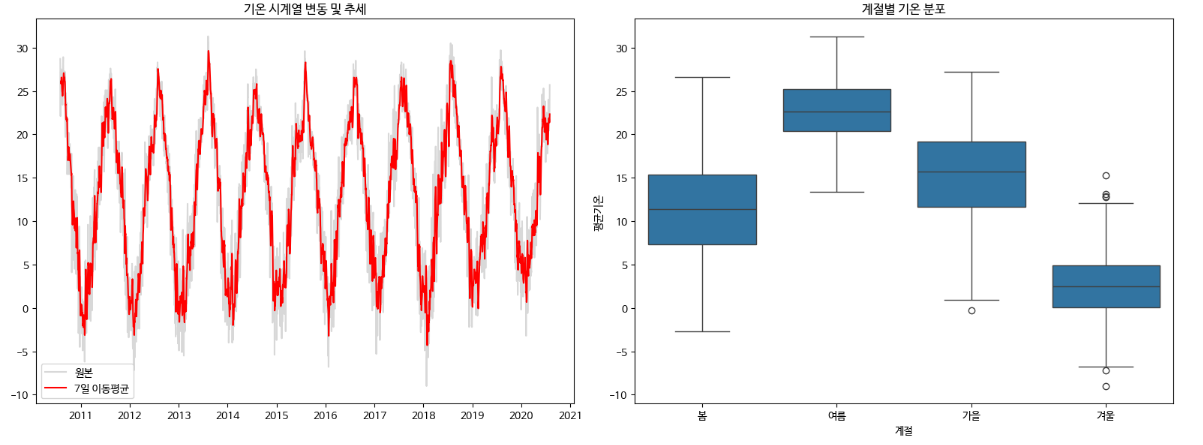

  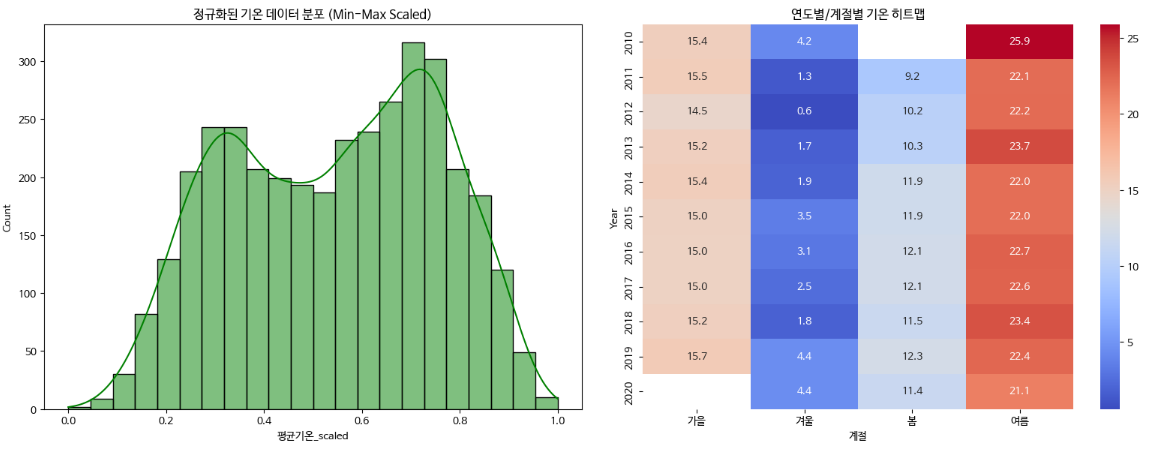



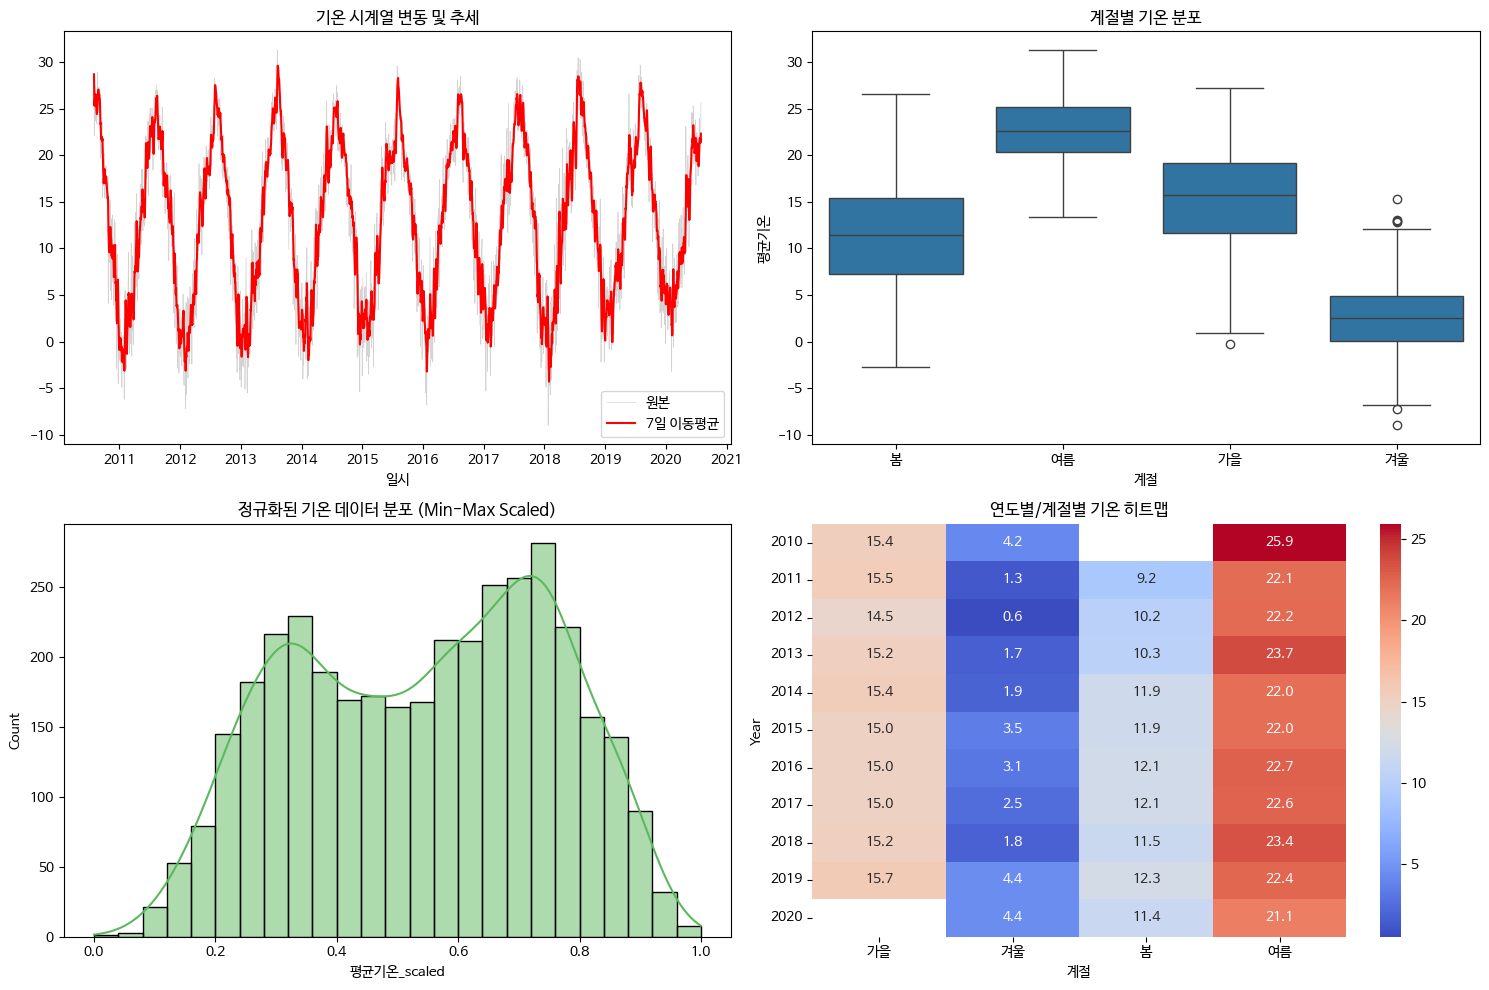

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

def load_data(url):
    df = pd.read_csv(url, encoding='cp949')
    return df

def preprocess_data(df):
    df['일시'] = pd.to_datetime(df['일시'])
    df.set_index('일시', inplace=True)

    df['평균기온'] = df['평균기온'].interpolate()

    df['Year'] = df.index.year
    df['Month'] = df.index.month

    season_mapping = {
        12: '겨울', 1: '겨울', 2: '겨울',
        3: '봄', 4: '봄', 5: '봄',
        6: '여름', 7: '여름', 8: '여름',
        9: '가을', 10: '가을', 11: '가을'
    }
    df['계절'] = df['Month'].map(season_mapping)

    return df

def min_max_scaling(df):
    min_temp = df['평균기온'].min()
    max_temp = df['평균기온'].max()

    df['평균기온_scaled'] = (df['평균기온'] - min_temp) / (max_temp - min_temp)
    return df

def add_moving_average(df):
    df['7일 이동평균'] = df['평균기온'].rolling(window=7, min_periods=1).mean()
    return df

def restructure_data(df):
    ordered_seasons = ['봄', '여름', '가을', '겨울']

    season_mean = df.groupby('계절')['평균기온'].mean()
    season_mean = season_mean.reindex(ordered_seasons)

    heatmap_df = df.pivot_table(values='평균기온', index='Year', columns='계절', aggfunc='mean')
    heatmap_df = heatmap_df[['가을', '겨울', '봄', '여름']]

    return season_mean, heatmap_df

def visualize_all(df, heatmap_df):
    plt.figure(figsize=(15, 10))
    ordered_seasons = ['봄', '여름', '가을', '겨울']

    plt.subplot(2, 2, 1)
    sns.lineplot(x=df.index, y=df['평균기온'], color='lightgray', label='원본', linewidth=0.5)
    sns.lineplot(x=df.index, y=df['7일 이동평균'], color='red', label='7일 이동평균', linewidth=1.5)
    plt.title("기온 시계열 변동 및 추세", fontsize=12)
    plt.ylabel("")

    plt.subplot(2, 2, 2)
    sns.boxplot(data=df, x='계절', y='평균기온', order=ordered_seasons, color='tab:blue')
    plt.title("계절별 기온 분포", fontsize=12)

    plt.subplot(2, 2, 3)
    sns.histplot(df['평균기온_scaled'], kde=True, color='#5cb85c', bins=25)
    plt.title("정규화된 기온 데이터 분포 (Min-Max Scaled)", fontsize=12)

    plt.subplot(2, 2, 4)
    sns.heatmap(heatmap_df, cmap='coolwarm', annot=True, fmt=".1f", cbar_kws={'label': ''})
    plt.title("연도별/계절별 기온 히트맵", fontsize=12)

    plt.tight_layout()
    plt.show()

def export_excel(df, season_mean, heatmap_df):
    with pd.ExcelWriter('weather_analysis_report.xlsx') as writer:
        df.reset_index().to_excel(writer, sheet_name='전처리_데이터', index=False)
        season_mean.to_excel(writer, sheet_name='계절별_평균기온')
        heatmap_df.to_excel(writer, sheet_name='연도별_계절별_피벗')

def main():
    url = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"

    raw_df = load_data(url)
    prep_df = preprocess_data(raw_df)
    scaled_df = min_max_scaling(prep_df)
    final_df = add_moving_average(scaled_df)

    season_mean, heatmap_df = restructure_data(final_df)

    visualize_all(final_df, heatmap_df)
    export_excel(final_df, season_mean, heatmap_df)

main()